# Out-of-Sample Walk-Forward Backtesting
This notebook executes out-of-sample (OOS) walk-forward backtesting for the 4 key alternative data signals identified in `strongest_correlations.csv` (`to_backtest == TRUE`).

For each pair of alternative data (predictor variable) and quarterly metric (target variable),
- A **rolling average or count** of the alternative data is generated using the optimal time window $W$ for that pair, found in `Lead_Lag_Analysis.ipynb`.
- The timestamps of the alternative data are shifted by the optimal lag $L$ to **align** with the quarterly release dates.
- Backtests are initialized with a training window of $K=10$ quarters. At each step $t$, a **linear regression** model is **trained only on past quarters** $[0 \dots t-1]$ to forecast the next unseen quarter $\hat{y}_t$.
- Evaluation metrics of backtests:
   - **MAPE (%)**: Mean absolute percentage error
   - **RMSE**: Root mean squared error
   - **Directional hit rate (%)**: Directional accuracy of predicted change in metric compared to actual changes
   - **Average risk-to-reward ratio**: Average error on incorrect calls compared to average actual move magnitude on correct calls


In [18]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
from typing import Union, Tuple
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Set directory paths
CODE_DIR = Path(os.path.abspath('')).resolve()
if CODE_DIR.name != 'Code' and (CODE_DIR / 'Code').exists():
    ROOT_DIR = CODE_DIR
    CODE_DIR = ROOT_DIR / 'Code'
else:
    ROOT_DIR = CODE_DIR.parent

DATA_DIR = ROOT_DIR / 'Data'
RESULTS_DIR = ROOT_DIR / 'Results'
SUMMARIES_DIR = RESULTS_DIR / 'Summaries'
SUMMARIES_DIR.mkdir(parents=True, exist_ok=True)

print(f"ROOT_DIR: {ROOT_DIR}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"SUMMARIES_DIR: {SUMMARIES_DIR}")


ROOT_DIR: C:\Users\limli\Documents\Job Applications\Assignments\FUNDA
DATA_DIR: C:\Users\limli\Documents\Job Applications\Assignments\FUNDA\Data
SUMMARIES_DIR: C:\Users\limli\Documents\Job Applications\Assignments\FUNDA\Results\Summaries


## Load data from CSV

In [19]:
# Load quarterly metrics
df_metrics = pd.read_csv(DATA_DIR / 'qtrly_metrics.csv')
df_metrics['timestamp_utc'] = pd.to_datetime(df_metrics['timestamp_utc'])
df_metrics = df_metrics.set_index('timestamp_utc').sort_index()

# Load raw alternative data series
# NASDAQ:PYPL returns
s_pypl_returns = pd.read_csv(
    DATA_DIR / 'pypl_returns.csv', 
    parse_dates=['timestamp_utc']
).set_index('timestamp_utc')['return'].dropna().sort_index()

# Cloud tech-related news headlines score
s_tech_headlines = pd.read_csv(
    DATA_DIR / 'tech_headlines.csv', 
    parse_dates=['timestamp_utc']
).set_index('timestamp_utc')['news_score'].dropna().sort_index()

# Datadog product releases frequency
s_announcements = pd.read_csv(
    DATA_DIR / 'announcements.csv', 
    parse_dates=['timestamp_utc']
)
s_announcements = s_announcements[s_announcements['product_release'] == True].set_index('timestamp_utc')['product_release'].sort_index()

# Rolling generator functions
def get_rolling_pypl(window_days: int) -> pd.Series:
    return s_pypl_returns.rolling(f'{window_days}D', min_periods=1).mean()

def get_rolling_tech_headlines(window_days: int) -> pd.Series:
    return s_tech_headlines.rolling(f'{window_days}D', min_periods=1).mean()

def get_rolling_announcements(window_days: int) -> pd.Series:
    return s_announcements.resample('D').size().rolling(f'{window_days}D', min_periods=1).sum()

# Load strongest_correlations.csv and filter for to_backtest == TRUE
df_strongest = pd.read_csv(SUMMARIES_DIR / 'strongest_correlations.csv')
df_backtest_pairs = df_strongest[
    df_strongest['to_backtest'].astype(str).str.strip().str.upper().isin(['TRUE', '1'])
].copy().reset_index(drop=True)

print(f"Loaded {len(df_backtest_pairs)} pairs of alternative data and Datadog's quarterly metric to backtest:")
display(df_backtest_pairs[['source', 'metric', 'optimal window', 'optimal lag', 'hy estimator']])


Loaded 4 pairs of alternative data and Datadog's quarterly metric to backtest:


,source,metric,optimal window,optimal lag,hy estimator
0,Product Releases Frequency,Revenue QoQ Growth Rate (%),71,88,-0.6345
1,Tech Headlines Score,RPO YoY Growth Rate (%),9,71,-0.2310
2,PYPL Returns,Billings YoY Growth Rate (%),90,77,-0.4958
3,PYPL Returns,Large Customer QoQ Growth Rate (%),90,20,-0.4396


## Functions

In [20]:
# Map metric names to df_metrics columns and styling
metric_col_map = {
    'Revenue QoQ Growth Rate (%)': {'col': 'revenue_qoq (%)', 'color': '#3182bd', 'type': 'pct'},
    'RPO YoY Growth Rate (%)': {'col': 'rpo_yoy (%)', 'color': '#fd8d3c', 'type': 'pct'},
    'Billings YoY Growth Rate (%)': {'col': 'billings_yoy (%)', 'color': '#74c476', 'type': 'pct'},
    'Large Customer QoQ Growth Rate (%)': {'col': 'large_customer_qoq (%)', 'color': '#756bb1', 'type': 'pct'},
    'Revenue YoY Growth Rate (%)': {'col': 'revenue_yoy (%)', 'color': '#6baed6', 'type': 'pct'},
    'RPO QoQ Growth Rate (%)': {'col': 'rpo_qoq (%)', 'color': '#e6550d', 'type': 'pct'},
    'Billings QoQ Growth Rate (%)': {'col': 'billings_qoq (%)', 'color': '#31a354', 'type': 'pct'},
    'Large Customer YoY Growth Rate (%)': {'col': 'large_customer_yoy (%)', 'color': '#9e9ac8', 'type': 'pct'},
}

def extract_time_and_values(
    data: Union[pd.Series, np.ndarray, list, Tuple[np.ndarray, np.ndarray]]
) -> Tuple[np.ndarray, np.ndarray]:
    if isinstance(data, pd.Series):
        values = data.to_numpy(dtype=np.float64)
        if isinstance(data.index, pd.DatetimeIndex):
            timestamps = data.index.astype(np.int64) / 1e9
        else:
            timestamps = np.asarray(data.index, dtype=np.float64)
    else:
        raise ValueError("Expected pd.Series.")
    sort_idx = np.argsort(timestamps)
    return timestamps[sort_idx], values[sort_idx]

def align_timestamps(s1: pd.Series, s2: pd.Series, s1_lag_days: int = 0):
    '''
    Time-shifts s1 by `s1_lag_days` days and aligns the values with s2.
    Returns: aligned_s1_values, aligned_s2_values, valid_timestamps (s2 index)
    '''
    if s1_lag_days is None:
        s1_lag_days = 0

    t1, raw_data1 = extract_time_and_values(s1)
    t2, raw_data2 = extract_time_and_values(s2)

    # Shift s1 timestamps forward by lag_days
    t1 = t1 + 86400 * s1_lag_days

    start_time = max(t1[0], t2[0])
    end_time = min(t1[-1], t2[-1])

    valid_mask2 = (t2 >= start_time) & (t2 <= end_time)
    valid_t2 = t2[valid_mask2]
    data2 = raw_data2[valid_mask2]
    dates2 = s2.index[valid_mask2]

    matched_idx = np.searchsorted(t1, valid_t2, side='right') - 1
    data1 = raw_data1[matched_idx]

    return data1, data2, dates2


In [21]:
def run_walk_forward_backtest(
    s_predictor: pd.Series,
    s_target: pd.Series,
    lag_days: int,
    initial_train_size: int = 10
):
    """
    Executes walk-forward backtest for linear regression.
    """
    x, y, dates = align_timestamps(s_predictor, s_target, lag_days)
    n_samples = len(y)
    
    if n_samples <= initial_train_size:
        raise ValueError(f"Not enough samples ({n_samples}) for initial train size {initial_train_size}")
    
    oos_preds = []
    oos_actuals = []
    oos_dates = []
    oos_prior_actuals = [] # y_{t-1} for directional change evaluation
    
    for t in range(initial_train_size, n_samples):
        # Training strictly on historical data [0 .. t-1]
        x_train = x[:t].reshape(-1, 1)
        y_train = y[:t]
        
        # Unseen test sample at time t
        x_test = x[t].reshape(-1, 1)
        y_test = y[t]
        
        # Fit linear regression
        model = LinearRegression().fit(x_train, y_train)
        pred = model.predict(x_test)[0]
        
        oos_preds.append(pred)
        oos_actuals.append(y_test)
        oos_dates.append(dates[t])
        oos_prior_actuals.append(y[t-1])
        
    oos_preds = np.array(oos_preds)
    oos_actuals = np.array(oos_actuals)
    oos_prior_actuals = np.array(oos_prior_actuals)
    
    # MAPE
    eps = 1e-6
    safe_actuals = np.where(np.abs(oos_actuals) < eps, eps, oos_actuals)
    mape = np.mean(np.abs((oos_actuals - oos_preds) / safe_actuals)) * 100.0
    
    # RMSE
    rmse = np.sqrt(mean_squared_error(oos_actuals, oos_preds))
    
    # Directional hit rate
    actual_change = oos_actuals - oos_prior_actuals
    pred_change = oos_preds - oos_prior_actuals
    
    correct_dir = (np.sign(pred_change) == np.sign(actual_change))
    directional_hit_rate = np.mean(correct_dir) * 100.0
    
    # Average risk-to-reward ratio
    # Average error on incorrect calls vs Average actual move magnitude on correct calls
    errors = np.abs(oos_actuals - oos_preds)
    actual_move_magnitudes = np.abs(actual_change)
    
    avg_loss_magnitude = np.mean(errors[~correct_dir]) if np.sum(~correct_dir) > 0 else 0.0
    avg_win_magnitude = np.mean(actual_move_magnitudes[correct_dir]) if np.sum(correct_dir) > 0 else 1e-6
    
    avg_risk_to_reward = avg_loss_magnitude / avg_win_magnitude if avg_win_magnitude > 0 else np.nan
    
    df_oos_details = pd.DataFrame({
        'date': oos_dates,
        'actual': oos_actuals,
        'predicted': oos_preds,
        'prior_actual': oos_prior_actuals,
        'actual_change': actual_change,
        'pred_change': pred_change,
        'correct_direction': correct_dir,
        'error': errors
    })
    
    metrics = {
        'mape': mape,
        'rmse': rmse,
        'directional_hit_rate': directional_hit_rate,
        'avg_risk_to_reward': avg_risk_to_reward,
        'n_oos_quarters': len(oos_actuals)
    }
    
    return metrics, df_oos_details


## Walk-forward backtesting

In [25]:
backtest_results = []
detailed_oos_records = {}

print("=== Running out-of-sample walk-forward backtests ===\n")

for idx, row in df_backtest_pairs.iterrows():
    source_name = str(row['source']).strip()
    metric_name = str(row['metric']).strip()
    window_days = int(row['optimal window'])
    lag_days = int(row['optimal lag'])
    hy_val = float(row['hy estimator'])
    
    # Get predictors
    if 'PYPL' in source_name:
        s_pred = get_rolling_pypl(window_days)
    elif 'Tech Headlines' in source_name:
        s_pred = get_rolling_tech_headlines(window_days)
    elif 'Product Releases' in source_name or 'Announcement' in source_name:
        s_pred = get_rolling_announcements(window_days)
    else:
        raise ValueError(f"Unknown source: {source_name}")
        
    # Get targets ie. quarterly metrics
    metric_info = metric_col_map.get(metric_name)
    if not metric_info:
        for k, v in metric_col_map.items():
            if k.lower() == metric_name.lower():
                metric_info = v
                break
    if not metric_info:
        raise ValueError(f"Could not find metric column for: {metric_name}")
        
    col_name = metric_info['col']
    s_target = df_metrics[col_name].dropna()
    
    # Run walk-forward backtest
    metrics, df_detail = run_walk_forward_backtest(
        s_predictor=s_pred,
        s_target=s_target,
        lag_days=lag_days,
        initial_train_size=10
    )
    
    pair_key = f"{source_name} -> {metric_name}"
    detailed_oos_records[pair_key] = (df_detail, metric_info)
    
    backtest_results.append({
        'source': source_name,
        'metric': metric_name,
        'optimal window': window_days,
        'optimal lag': lag_days,
        'hy estimator': hy_val,
        'mape (%)': round(metrics['mape'], 2),
        'rmse': round(metrics['rmse'], 2),
        'directional_hit_rate (%)': round(metrics['directional_hit_rate'], 2),
        'avg_risk_to_reward_ratio': round(metrics['avg_risk_to_reward'], 2),
        'oos_quarters_tested': metrics['n_oos_quarters']
    })
    
    print(f"[{idx+1}/4] {pair_key}")
    print(f"      Window={window_days}d, Lag={lag_days}d | OOS Quarters={metrics['n_oos_quarters']}")
    print(f"      MAPE: {metrics['mape']:.2f}% | RMSE: {metrics['rmse']:.2f} | Hit rate: {metrics['directional_hit_rate']:.1f}% | Avg risk/reward: {metrics['avg_risk_to_reward']:.2f}\n")

df_summary = pd.DataFrame(backtest_results)


=== Running out-of-sample walk-forward backtests ===

[1/4] Product Releases Frequency -> Revenue QoQ Growth Rate (%)
      Window=71d, Lag=88d | OOS Quarters=19
      MAPE: 96.91% | RMSE: 5.75 | Hit rate: 57.9% | Avg risk/reward: 2.37

[2/4] Tech Headlines Score -> RPO YoY Growth Rate (%)
      Window=9d, Lag=71d | OOS Quarters=14
      MAPE: 64.38% | RMSE: 26.57 | Hit rate: 57.1% | Avg risk/reward: 1.89

[3/4] PYPL Returns -> Billings YoY Growth Rate (%)
      Window=90d, Lag=77d | OOS Quarters=13
      MAPE: 92.39% | RMSE: 24.33 | Hit rate: 69.2% | Avg risk/reward: 4.98

[4/4] PYPL Returns -> Large Customer QoQ Growth Rate (%)
      Window=90d, Lag=20d | OOS Quarters=17
      MAPE: 153.20% | RMSE: 5.19 | Hit rate: 41.2% | Avg risk/reward: 3.29



## Comparison of predicted vs actual trajectories

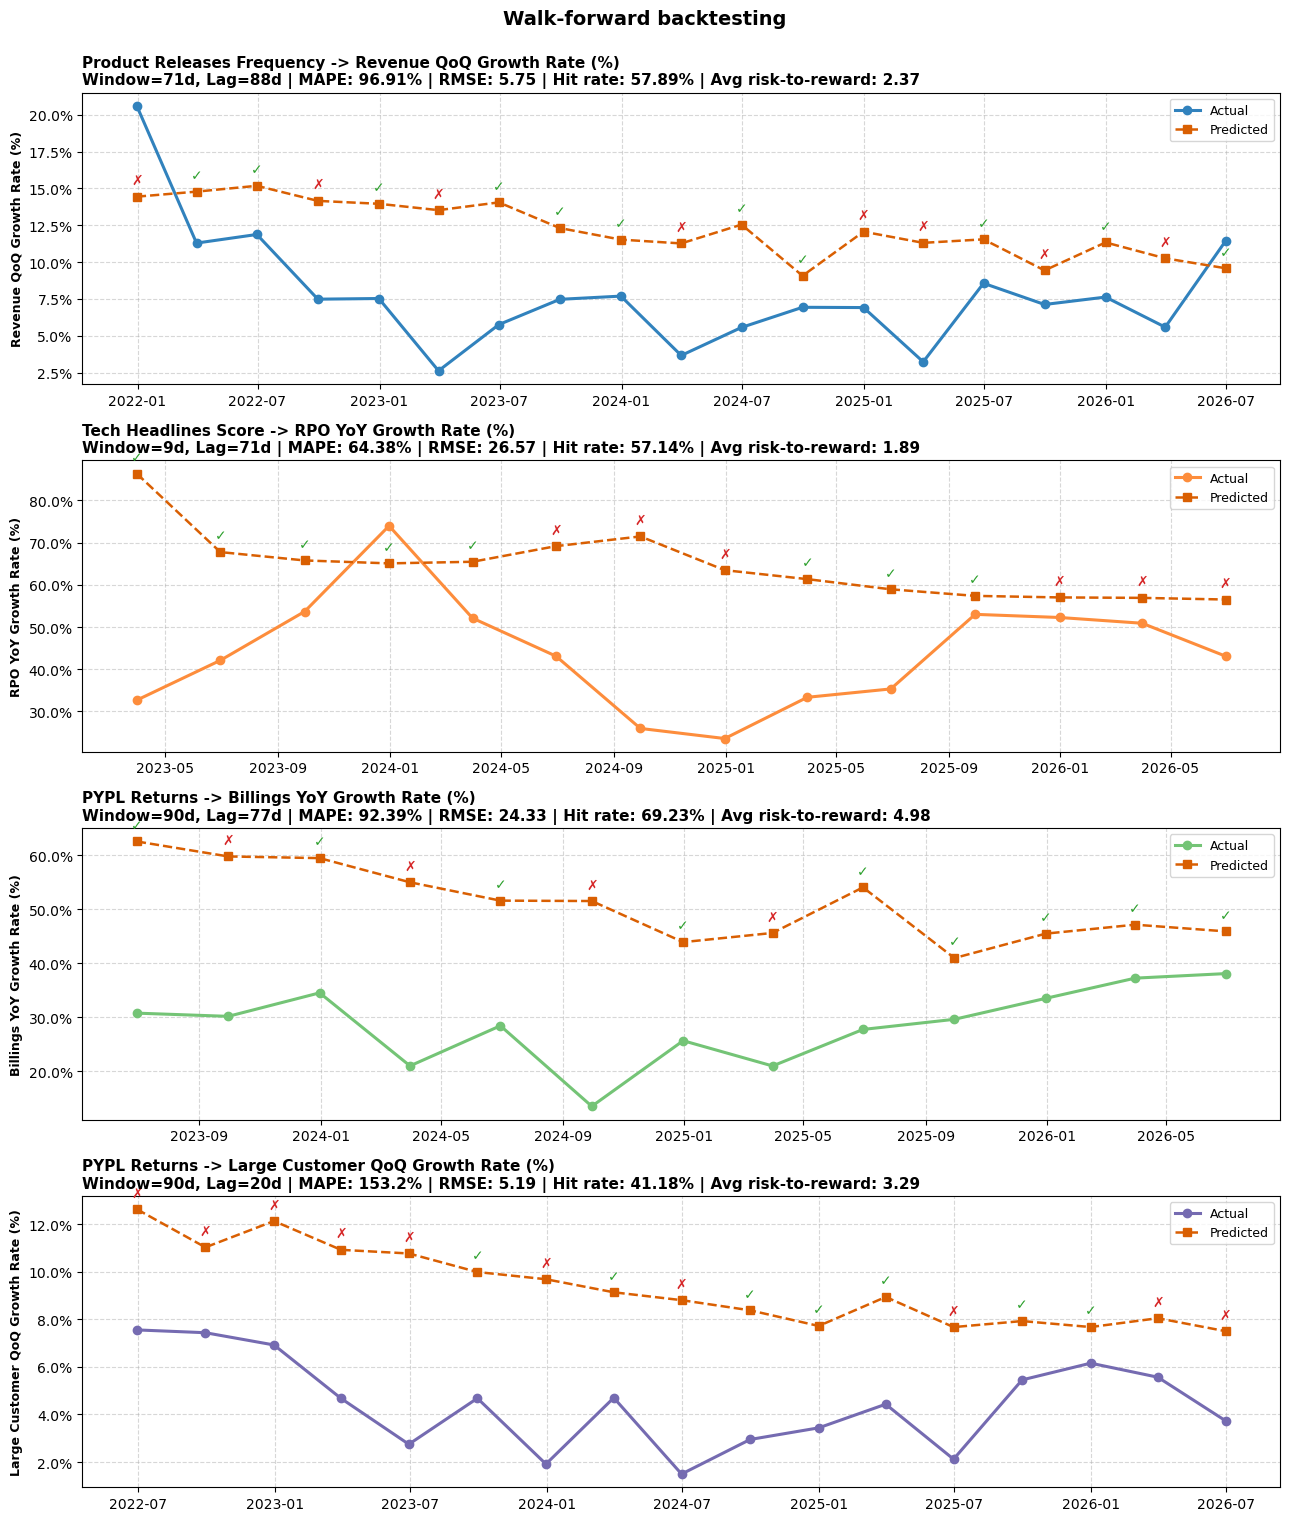

Saved plot to C:\Users\limli\Documents\Job Applications\Assignments\FUNDA\Results\walkforward_backtest.png


In [26]:
# Plot backtesting predicted trajectories
n_pairs = len(detailed_oos_records)
fig, axes = plt.subplots(n_pairs, 1, figsize=(13, 3.8 * n_pairs), sharex=False)
if n_pairs == 1:
    axes = [axes]

for i, (pair_name, (df_detail, metric_info)) in enumerate(detailed_oos_records.items()):
    ax = axes[i]
    color = metric_info['color']
    dates = df_detail['date']
    
    # Plot actual values
    ax.plot(dates, df_detail['actual'], marker='o', color=color, linewidth=2.2, label='Actual')
    
    # Plot predicted values
    ax.plot(dates, df_detail['predicted'], marker='s', linestyle='--', color='#d95f02', linewidth=1.8, label='Predicted')
    
    # Annotate hit / miss directional calls
    for _, row in df_detail.iterrows():
        d = row['date']
        pred_val = row['predicted']
        is_hit = row['correct_direction']
        marker_symbol = '✓' if is_hit else '✗'
        marker_color = '#2ca02c' if is_hit else '#d62728'
        ax.annotate(
            marker_symbol,
            (d, pred_val),
            textcoords="offset points",
            xytext=(0, 9),
            ha='center',
            fontsize=10,
            fontweight='bold',
            color=marker_color
        )
        
    summary_row = df_summary[df_summary.apply(lambda r: f"{r['source']} -> {r['metric']}" == pair_name, axis=1)].iloc[0]
    title_str = (
        f"{pair_name}\n"
        f"Window={summary_row['optimal window']}d, Lag={summary_row['optimal lag']}d | "
        f"MAPE: {summary_row['mape (%)']}% | RMSE: {summary_row['rmse']} | "
        f"Hit rate: {summary_row['directional_hit_rate (%)']}% | Avg risk-to-reward: {summary_row['avg_risk_to_reward_ratio']}"
    )
    
    ax.set_title(title_str, fontsize=11, fontweight='bold', loc='left')
    ax.set_ylabel(summary_row['metric'], fontsize=9, fontweight='semibold')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{val:.1f}%'))
    ax.legend(loc='best', fontsize=9)

plt.suptitle("Walk-forward backtesting", fontsize=14, fontweight='bold', y=0.998)
plt.tight_layout()
plot_path = RESULTS_DIR / 'walkforward_backtest.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved plot to {plot_path}")


## Save results to CSV

In [27]:
# Save summary table to CSV
csv_path = SUMMARIES_DIR / 'backtesting_summary.csv'
df_summary.to_csv(csv_path, index=False)
print(f"Saved summary CSV to: {csv_path}")

Saved summary CSV to: C:\Users\limli\Documents\Job Applications\Assignments\FUNDA\Results\Summaries\backtesting_summary.csv
